In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# Load the dataset
df = pd.read_csv("/content/Airline_review_assignment_data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      23171 non-null  int64  
 1   Airline Name            23171 non-null  object 
 2   Overall_Rating          23171 non-null  object 
 3   Review_Title            23171 non-null  object 
 4   Review Date             23171 non-null  object 
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  object 
 7   Aircraft                7129 non-null   object 
 8   Type Of Traveller       19433 non-null  object 
 9   Seat Type               22075 non-null  object 
 10  Route                   19343 non-null  object 
 11  Date Flown              19417 non-null  object 
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverages        14500 non-null

In [ ]:
df.head()

,ID,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,Nov-19,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,Jun-19,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,Jun-19,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,Sep-19,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,Sep-19,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [ ]:
df.describe()

,ID,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money
count,23171.00000,19016.000000,18911.000000,14500.000000,18378.000000,10829.000000,5920.000000,22105.000000
mean,11585.00000,2.618374,2.871609,2.553586,2.353738,2.179056,1.780405,2.451165
std,6689.03588,1.464840,1.604631,1.526314,1.595747,1.488839,1.318800,1.594155
min,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,5792.50000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,11585.00000,3.000000,3.000000,2.000000,1.000000,2.000000,1.000000,2.000000
75%,17377.50000,4.000000,4.000000,4.000000,4.000000,3.000000,2.000000,4.000000
max,23170.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
df.isnull().sum()

,0
ID,0
Airline Name,0
Overall_Rating,0
Review_Title,0
Review Date,0
Verified,0
Review,0
Aircraft,16042
Type Of Traveller,3738
Seat Type,1096


In [ ]:
from dateutil import parser

# Convert 'Review Date' using dateutil's parser
df['Review Date'] = df['Review Date'].apply(lambda x: parser.parse(x) if pd.notnull(x) else pd.NaT)

# Convert 'Date Flown' in proper formar
df['Date Flown'] = pd.to_datetime(df['Date Flown'], format='%b-%y', errors='coerce')

converted_dates = df[['Review Date', 'Date Flown']].head()
converted_dates

# Impute missing 'Date Flown' values with 'Review Date' values
df['Date Flown'].fillna(df['Review Date'], inplace=True)

<ipython-input-52-adae1450ed67>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Date Flown'].fillna(df['Review Date'], inplace=True)


<Figure size 1200x700 with 0 Axes>

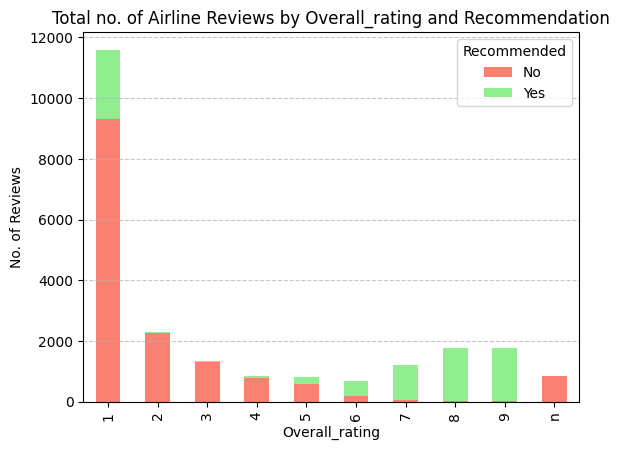

In [ ]:
# Count the frequency of Overall_rating with respect to recommendation
Overall_rating_recommendation_counts = df.groupby(['Overall_Rating', 'Recommended']).size().unstack()

# Plotting
plt.figure(figsize=(12, 7))
Overall_rating_recommendation_counts.plot(kind='bar', stacked=True, color=['salmon', 'lightgreen'])
plt.xlabel('Overall_rating')
plt.ylabel('No. of Reviews')
plt.title('Total no. of Airline Reviews by Overall_rating and Recommendation')
plt.legend(title='Recommended', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("Original Overall Rating Counts by Recommendation:")
display(Overall_rating_recommendation_counts)

Original Overall Rating Counts by Recommendation:


Recommended,no,yes
Overall_Rating,,
1,9327,2268
2,2264,32
3,1304,52
4,777,82
5,567,263
6,181,494
7,63,1130
8,35,1722
9,9,1759


In [ ]:
# impute the "n" with 1 and 9, with 1 if Recommendation is "no" otherwiswe with 9
df.loc[(df['Overall_Rating'] == 'n') & (df['Recommended'] == 'no'), 'Overall_Rating'] = '1'
df.loc[(df['Overall_Rating'] == 'n') & (df['Recommended'] == 'yes'), 'Overall_Rating'] = '9'


In [ ]:
# convert the Overall_Rating to Numeric
df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')

In [ ]:
# Impute missing categorical data with the mode ( frequent category)
df['Aircraft'].fillna(df['Aircraft'].mode()[0], inplace=True)
df['Type Of Traveller'].fillna(df['Type Of Traveller'].mode()[0], inplace=True)
df['Seat Type'].fillna(df['Seat Type'].mode()[0], inplace=True)
df['Route'].fillna(df['Route'].mode()[0], inplace=True)


# Impute missing numerical data with the median
df['Seat Comfort'].fillna(df['Seat Comfort'].median(), inplace=True)
df['Cabin Staff Service'].fillna(df['Cabin Staff Service'].median(), inplace=True)
df['Food & Beverages'].fillna(df['Food & Beverages'].median(), inplace=True)
df['Ground Service'].fillna(df['Ground Service'].median(), inplace=True)
df['Value For Money'].fillna(df['Value For Money'].median(), inplace=True)


# Impute InflightEntairtaiment and Wifi & Connectivity with 0
df['Inflight Entertainment'].fillna(0, inplace=True)
df['Wifi & Connectivity'].fillna(0, inplace=True)


<ipython-input-57-ef42d0a64e6e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Aircraft'].fillna(df['Aircraft'].mode()[0], inplace=True)
<ipython-input-57-ef42d0a64e6e>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

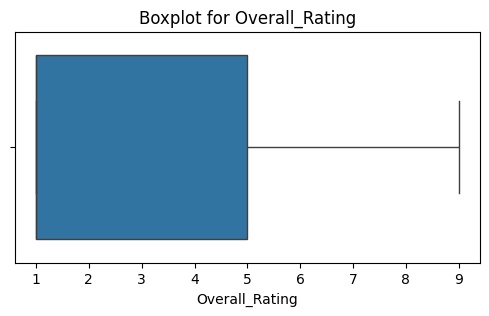

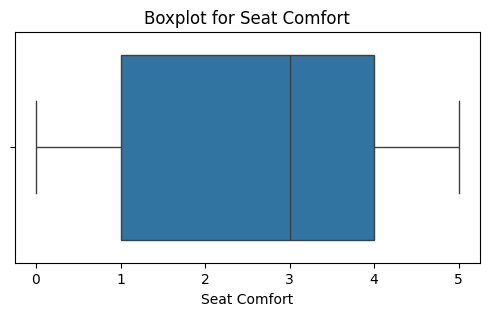

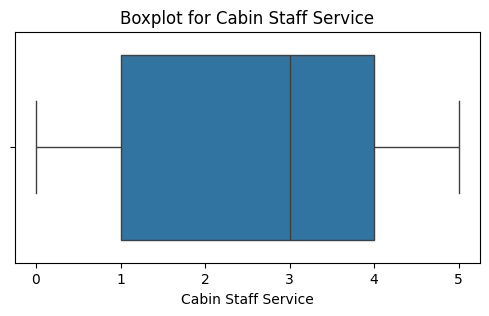

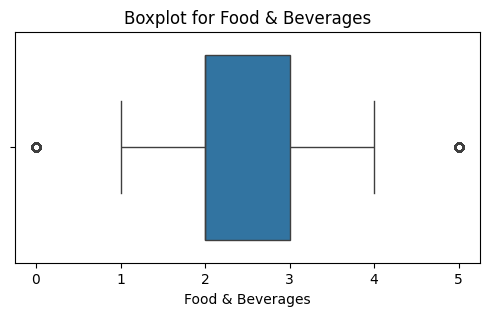

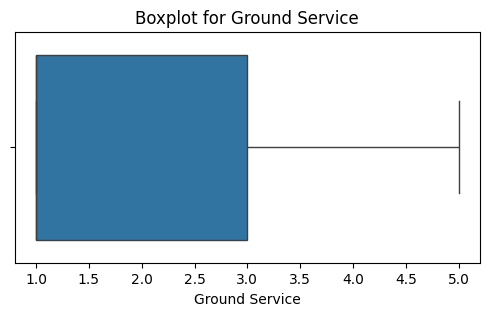

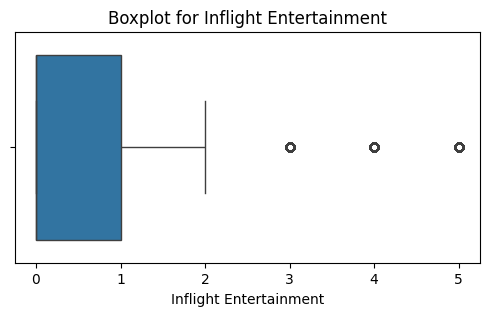

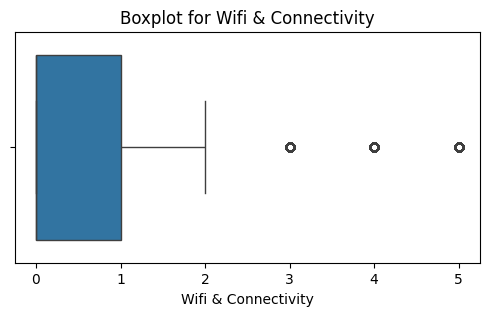

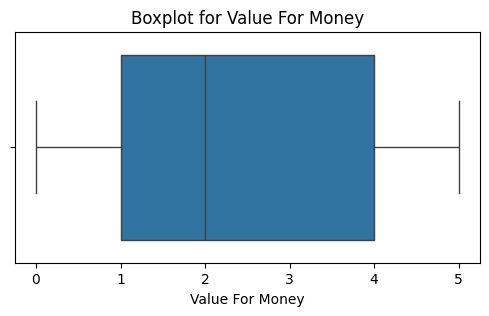

In [ ]:
numeric_cols = ['Overall_Rating', 'Seat Comfort', 'Cabin Staff Service',
                'Food & Beverages', 'Ground Service',
                'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money']


for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()


In [ ]:
# Convert the 'Recommended' column from 'yes'/'no' to 1/0
df['Recommended'] = df['Recommended'].map({'yes': 1, 'no': 0})

# Display the first few rows to verify changes
df['Recommended'].head()


,Recommended
0,1
1,0
2,0
3,0
4,0


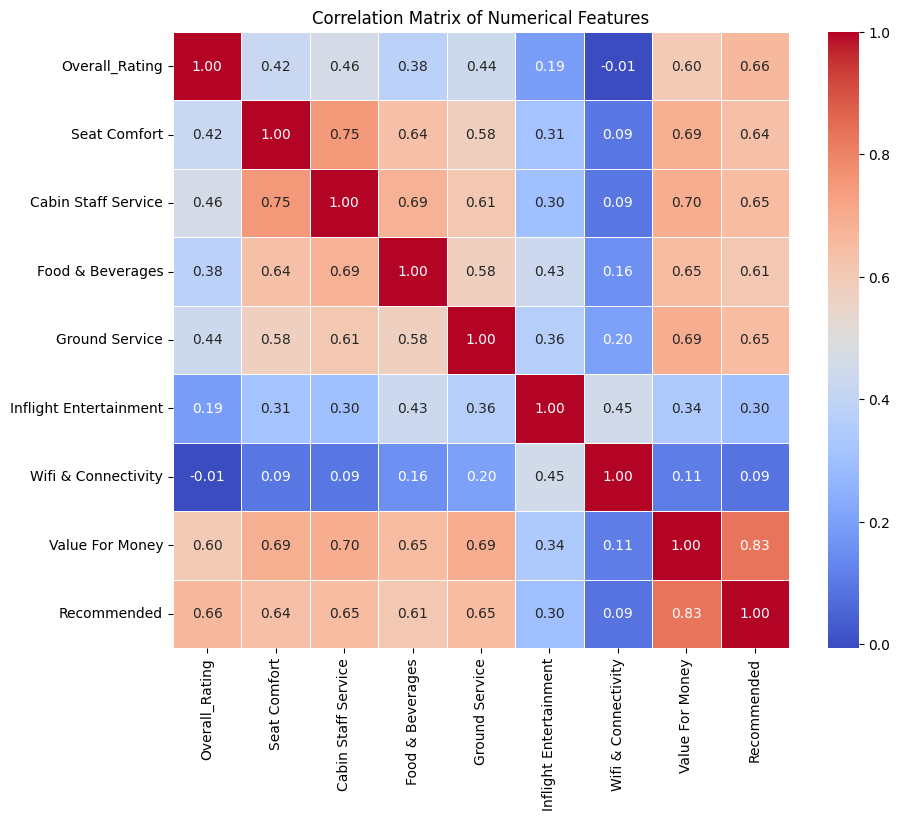

In [ ]:
# Compute the correlation matrix for numerical features
numeric_cols = ['Overall_Rating', 'Seat Comfort', 'Cabin Staff Service',
                'Food & Beverages', 'Ground Service',
                'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money']

correlation_matrix = df[numeric_cols + ['Recommended']].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


In [ ]:
selected_features = ['Value For Money', 'Overall_Rating', 'Cabin Staff Service',
    'Seat Comfort', 'Ground Service', 'Food & Beverages']

In [ ]:
df.head()

,ID,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",2019-11-11,True,Moroni to Moheli. Turned out to be a pretty ...,A320,Solo Leisure,Economy Class,Moroni to Moheli,2019-11-01,4.0,5.0,4.0,4.0,0.0,0.0,3.0,1
1,1,AB Aviation,1,"""Not a good airline""",2019-06-25,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,2019-06-01,2.0,2.0,1.0,1.0,0.0,0.0,2.0,0
2,2,AB Aviation,1,"""flight was fortunately short""",2019-06-25,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,2019-06-01,2.0,1.0,1.0,1.0,0.0,0.0,2.0,0
3,3,Adria Airways,1,"""I will never fly again with Adria""",2019-09-28,False,Please do a favor yourself and do not fly wi...,A320,Solo Leisure,Economy Class,Frankfurt to Pristina,2019-09-01,1.0,1.0,2.0,1.0,0.0,0.0,1.0,0
4,4,Adria Airways,1,"""it ruined our last days of holidays""",2019-09-24,True,Do not book a flight with this airline! My fr...,A320,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,2019-09-01,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0


In [ ]:
# Data Analyitcs
# 4.a

# Show descriptive statistics for selected numerical features
df[numeric_cols].describe().transpose()



,count,mean,std,min,25%,50%,75%,max
Overall_Rating,23171.0,3.068146,2.856150,1.0,1.0,1.0,5.0,9.0
Seat Comfort,23171.0,2.686807,1.335065,0.0,1.0,3.0,4.0,5.0
Cabin Staff Service,23171.0,2.895214,1.450486,0.0,1.0,3.0,4.0,5.0
Food & Beverages,23171.0,2.346424,1.236760,0.0,2.0,2.0,3.0,5.0
Ground Service,23171.0,2.073713,1.523264,1.0,1.0,1.0,3.0,5.0
Inflight Entertainment,23171.0,1.018385,1.489282,0.0,0.0,0.0,1.0,5.0
Wifi & Connectivity,23171.0,0.454879,1.023369,0.0,0.0,0.0,1.0,5.0
Value For Money,23171.0,2.430409,1.559917,0.0,1.0,2.0,4.0,5.0


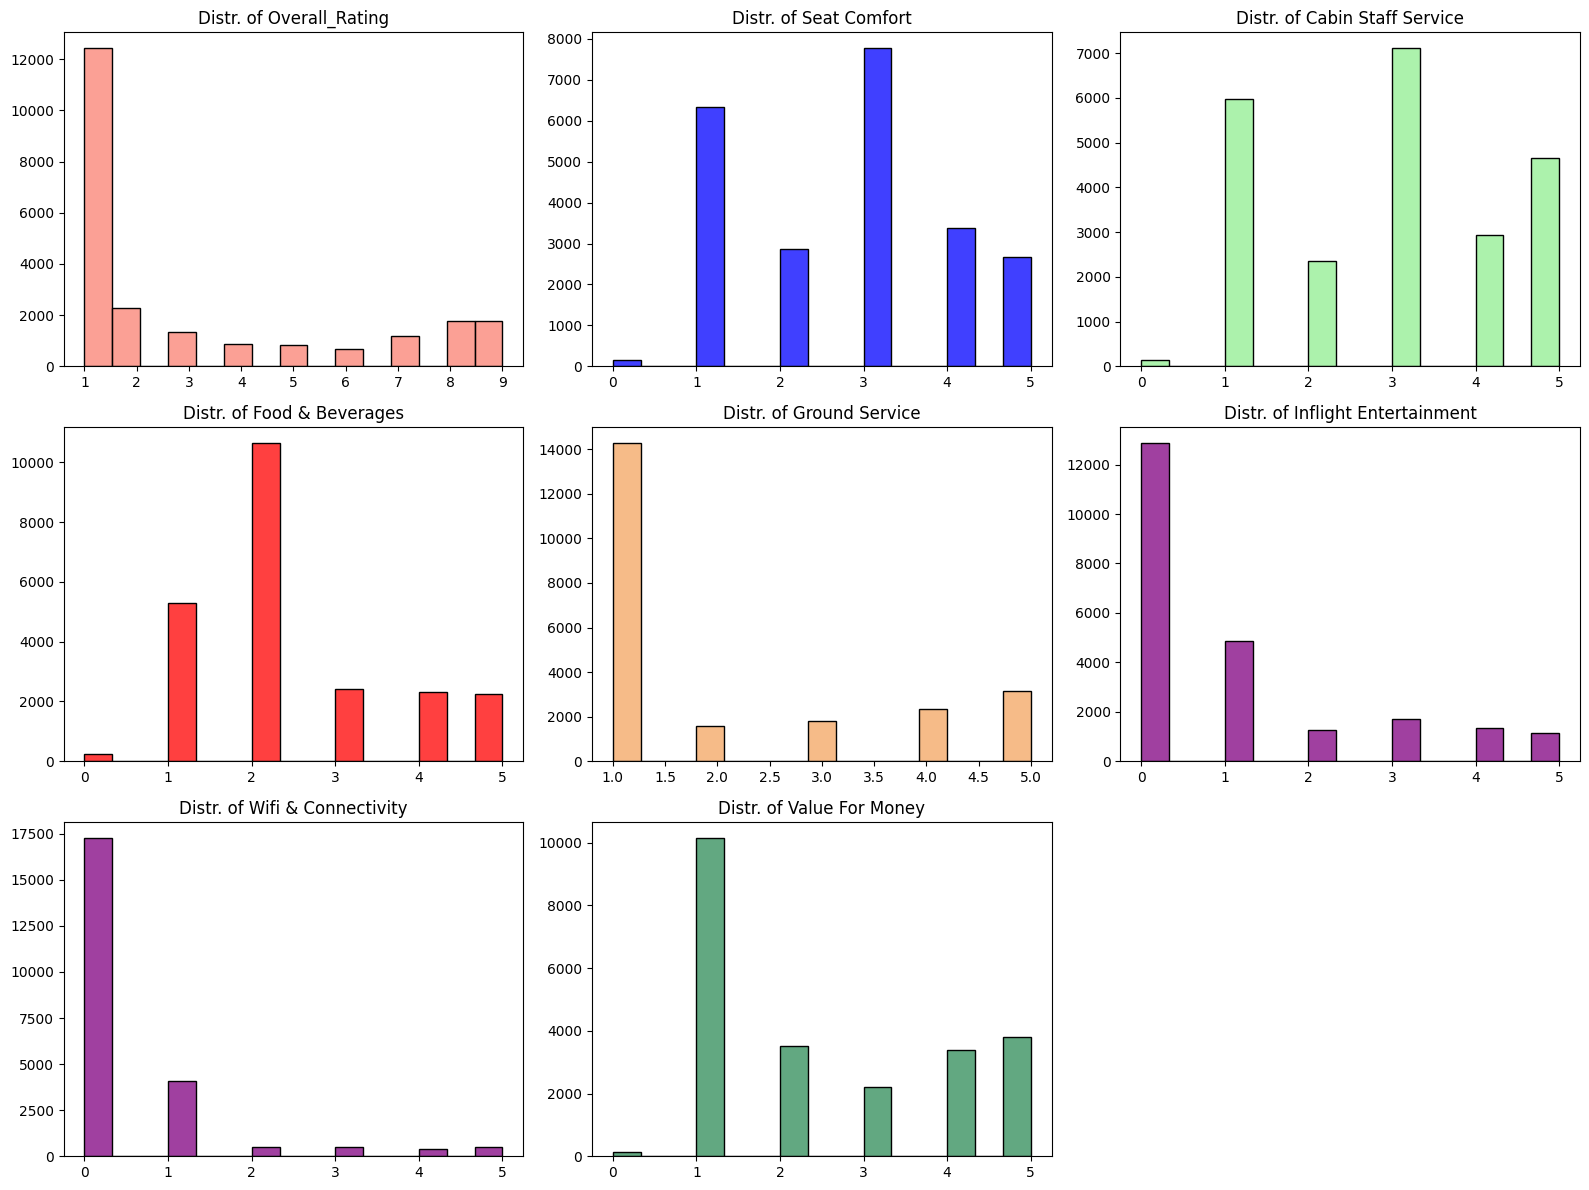

In [ ]:
# Distribution Charts
colors = ['salmon', 'blue', 'lightgreen', 'red', 'sandybrown', 'purple', 'purple', 'seagreen']
features = numeric_cols

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, (feature, color) in enumerate(zip(features, colors)):
    sns.histplot(df[feature], bins=15, ax=axes[i], color=color)
    axes[i].set_title(f'Distr. of {feature}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

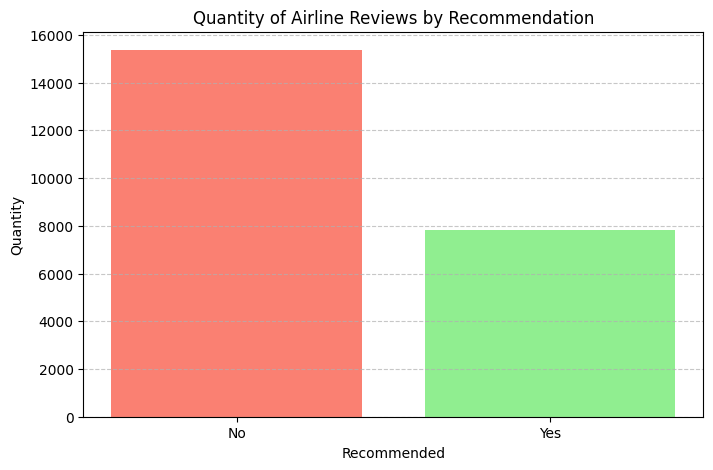

In [ ]:
# Quantity of Airlines Reviewes by recommendation
# Count the frequency of recommendations (1 for recommended, 0 for not recommended)
recommendation_counts = df['Recommended'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(recommendation_counts.index.astype(str), recommendation_counts.values, color=['salmon', 'lightgreen'])
plt.xlabel('Recommended')
plt.ylabel('Quantity')
plt.title('Quantity of Airline Reviews by Recommendation')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<ipython-input-90-7b6aaa9c7891>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Value For Money', y='Overall_Rating', data=df, ci=None, palette='YlGn')
<ipython-input-90-7b6aaa9c7891>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value For Money', y='Overall_Rating', data=df, ci=None, palette='YlGn')


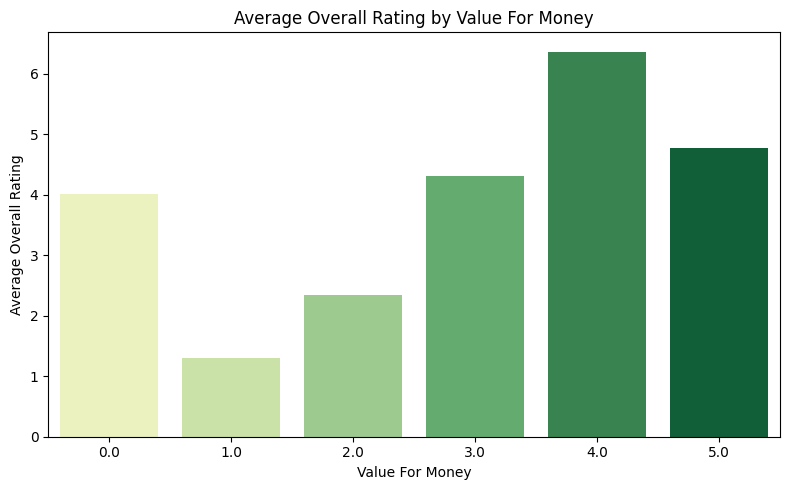

In [ ]:
# Barplot of Overall rating and Value for Money
plt.figure(figsize=(8, 5))
sns.barplot(x='Value For Money', y='Overall_Rating', data=df, ci=None, palette='YlGn')
plt.title('Average Overall Rating by Value For Money')
plt.xlabel('Value For Money')
plt.ylabel('Average Overall Rating')
plt.tight_layout()
plt.show()

<ipython-input-72-013793de675f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Value For Money', y='Overall_Rating', data=df, palette='pastel')


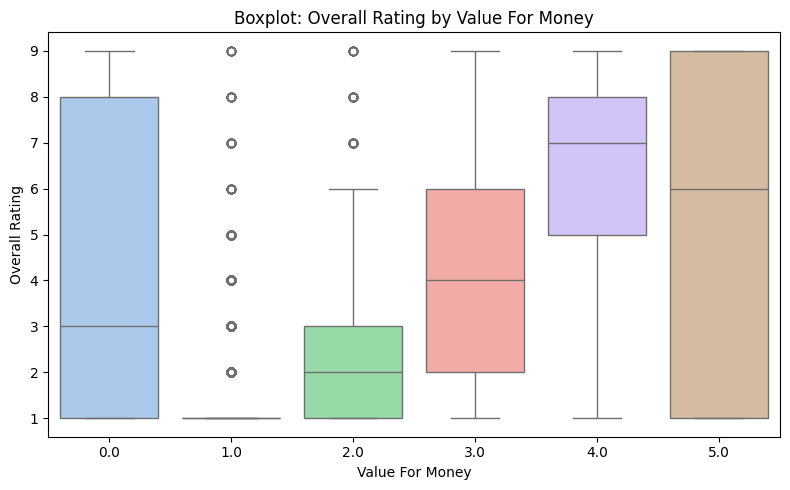

In [ ]:
# Boxplot of Overall Rating by Value for Money
plt.figure(figsize=(8, 5))
sns.boxplot(x='Value For Money', y='Overall_Rating', data=df, palette='pastel')
plt.title('Boxplot: Overall Rating by Value For Money')
plt.xlabel('Value For Money')
plt.ylabel('Overall Rating')
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

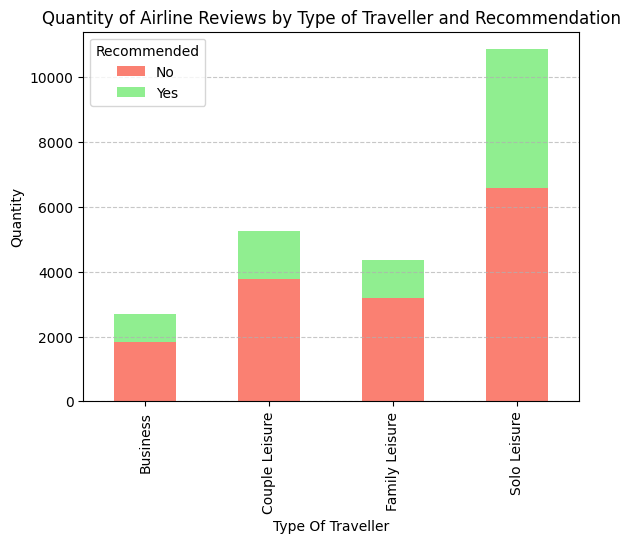

In [ ]:
# Quantity of Airline Reviews by Type of Traveller and Recommendation
# Count the frequency of each type of traveller with respect to recommendation
traveller_recommendation_counts = df.groupby(['Type Of Traveller', 'Recommended']).size().unstack()

# Plotting
plt.figure(figsize=(12, 7))
traveller_recommendation_counts.plot(kind='bar', stacked=True, color=['salmon', 'lightgreen'])
plt.xlabel('Type Of Traveller')
plt.ylabel('Quantity')
plt.title('Quantity of Airline Reviews by Type of Traveller and Recommendation')
plt.legend(title='Recommended', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

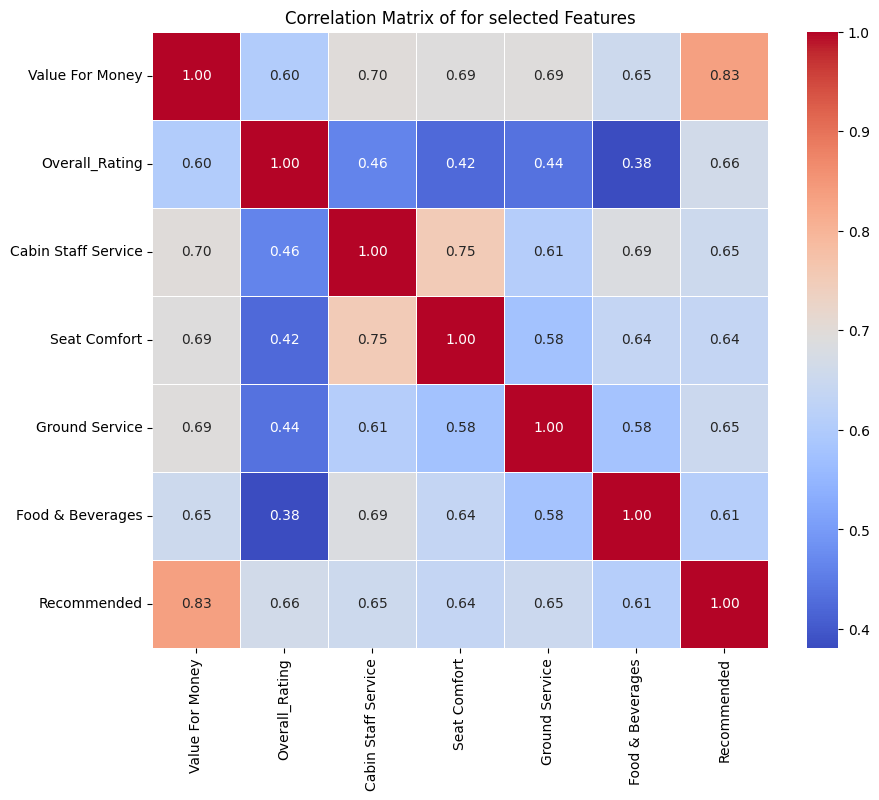

In [ ]:
# Correlation anlysis for selected features
# Compute the correlation matrix for selected features
correlation_matrix = df[selected_features + ['Recommended']].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5)
plt.title('Correlation Matrix of for selected Features')
plt.show()


In [ ]:
###########################
#  Predecitive Analytics Numeric
############################

In [ ]:
####################
# 1. Logistic
######################

Best C: {'C': 0.01}
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3065
           1       0.93      0.91      0.92      1570

    accuracy                           0.95      4635
   macro avg       0.94      0.94      0.94      4635
weighted avg       0.95      0.95      0.95      4635

AUC Score: 0.9759077731943766


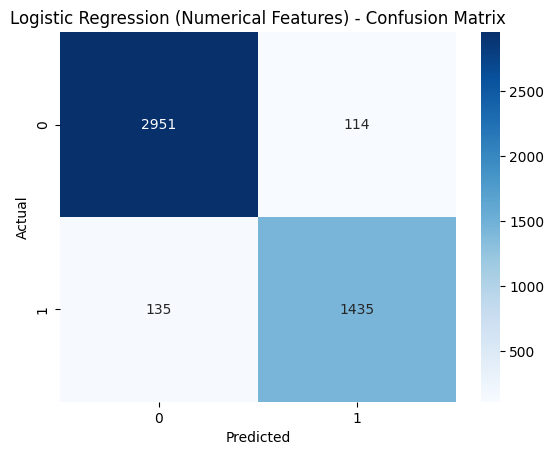

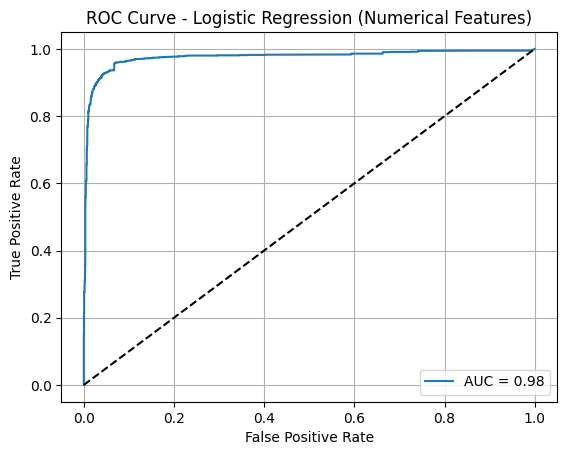

In [ ]:
# Select and scale
scaler = StandardScaler()
X_num = scaler.fit_transform(df[selected_features])
X_num_df = pd.DataFrame(X_num, columns=sel)

y = df['Recommended']

# Split
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num_df, y, test_size=0.2, random_state=42)

# Logistic Regression + Tuning
param_grid = {'C': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_num, y_train_num)

best_log_model = grid.best_estimator_

# Evaluate
y_pred = best_log_model.predict(X_test_num)
y_probs = best_log_model.predict_proba(X_test_num)[:, 1]

print("Best C:", grid.best_params_)
print(classification_report(y_test_num, y_pred))
print("AUC Score:", roc_auc_score(y_test_num, y_probs))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test_num, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression (Numerical Features) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_num, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_num, y_probs):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Logistic Regression (Numerical Features)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


<ipython-input-88-ed4247da390f>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='coolwarm')


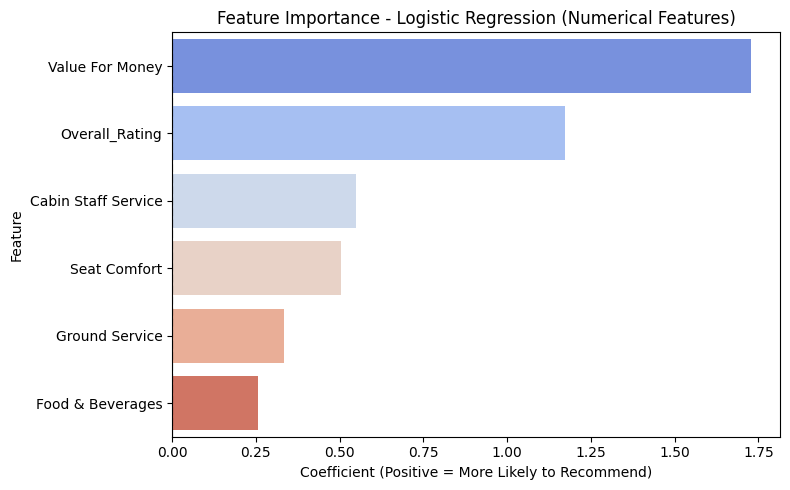

In [ ]:
# Feature Importance - Logistic Regression (Numerical Features)
# Get coefficients from trained model
coeffs = best_log_model.coef_[0]
features = selected_features

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coeffs,
    'Abs_Coefficient': np.abs(coeffs)
}).sort_values(by='Abs_Coefficient', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.axvline(0, color='black', linestyle='--')
plt.title("Feature Importance - Logistic Regression (Numerical Features)")
plt.xlabel("Coefficient (Positive = More Likely to Recommend)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Best Params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3065
           1       0.95      0.94      0.94      1570

    accuracy                           0.96      4635
   macro avg       0.96      0.96      0.96      4635
weighted avg       0.96      0.96      0.96      4635

AUC Score: 0.9907646429276504


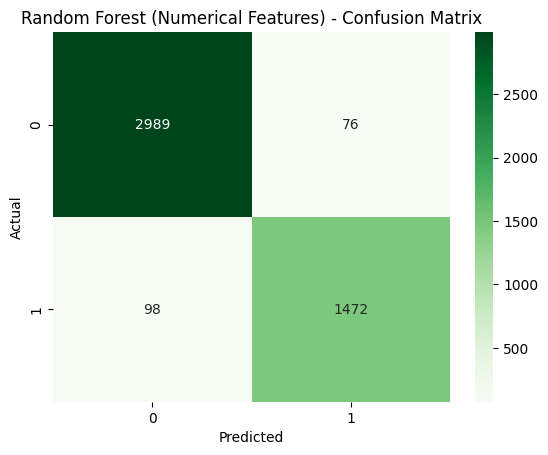

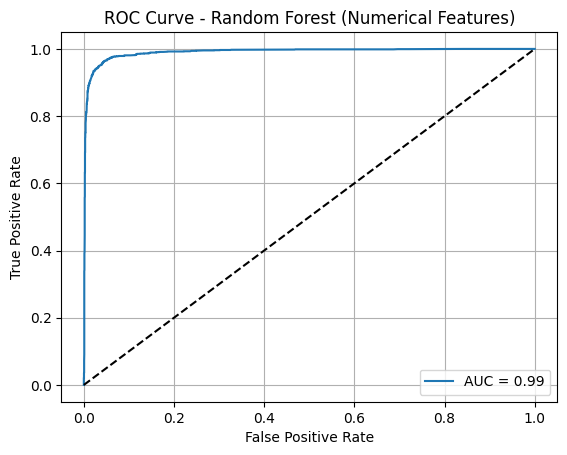

In [ ]:
#################################
## 2. RANDOM FOREST             ##
################################
# Select features and target
X_rf = df[selected_features]
y_rf = df['Recommended']

# Split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Random Forest + Tuning
param_grid_rf = {'n_estimators': [100],
                 'max_depth': [5, 10, None]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train_rf, y_train_rf)

best_rf_model = grid_rf.best_estimator_

# 4. Evaluate
y_pred_rf = best_rf_model.predict(X_test_rf)
y_probs_rf = best_rf_model.predict_proba(X_test_rf)[:, 1]

print("Best Params:", grid_rf.best_params_)
print(classification_report(y_test_rf, y_pred_rf))
print("AUC Score:", roc_auc_score(y_test_rf, y_probs_rf))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test_rf, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest (Numerical Features) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_probs_rf)
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_score(y_test_rf, y_probs_rf):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Random Forest (Numerical Features)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


<ipython-input-98-885aac033922>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance_df, x='Importance', y='Feature', palette='summer')


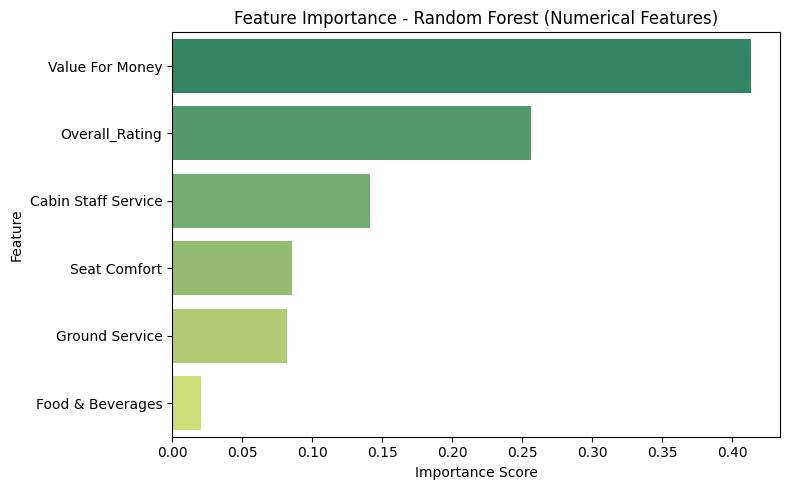

In [ ]:
# Feature Importance - Random Forest (Numerical Features)
# Get feature importances from the best Random Forest model
importances = best_rf_model.feature_importances_
features = selected_features

# Create DataFrame
rf_importance_df = pd.DataFrame({'Feature': features,
                                 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance_df, x='Importance', y='Feature', palette='summer')
plt.title("Feature Importance - Random Forest (Numerical Features)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
################################
#     TEXT CLEANING
################################

In [ ]:
df['Review'].head()

,Review
0,Moroni to Moheli. Turned out to be a pretty ...
1,Moroni to Anjouan. It is a very small airline...
2,Anjouan to Dzaoudzi. A very small airline an...
3,Please do a favor yourself and do not fly wi...
4,Do not book a flight with this airline! My fr...


In [ ]:
# Load stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define cleaning and tokenization function
def clean_tokenize_review(text):
    if pd.isnull(text):
        return []

    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return cleaned_tokens

# Apply to the 'Review' column
df['Cleaned_Review_Tokens'] = df['Review'].apply(clean_tokenize_review)

# Preview
df[['Review', 'Cleaned_Review_Tokens']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,Review,Cleaned_Review_Tokens
0,Moroni to Moheli. Turned out to be a pretty ...,"[moroni, moheli, turned, pretty, decent, airli..."
1,Moroni to Anjouan. It is a very small airline...,"[moroni, anjouan, small, airline, ticket, advi..."
2,Anjouan to Dzaoudzi. A very small airline an...,"[anjouan, dzaoudzi, small, airline, airline, b..."
3,Please do a favor yourself and do not fly wi...,"[please, favor, fly, adria, route, munich, pri..."
4,Do not book a flight with this airline! My fr...,"[book, flight, airline, friend, returned, sofi..."


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Join tokens back into text (CountVectorizer expects strings, not lists of tokens)
df['Cleaned_Review_Text'] = df['Cleaned_Review_Tokens'].apply(lambda tokens: ' '.join(tokens))

# Initialize CountVectorizer
vectorizer = CountVectorizer(max_features=1000)  # Limit to top 1000 most frequent words (adjust as needed)

# Fit and transform themcleaned review text
bow_matrix = vectorizer.fit_transform(df['Cleaned_Review_Text'])

# Convert to a DataFrame for easier analysis
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Preview
bow_df.head()


,able,absolute,absolutely,accept,acceptable,access,accommodation,across,actually,add,...,would,wouldnt,wrong,year,yes,yet,york,young,youre,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: title={'center': 'Top 20 Most Frequent Words'}>

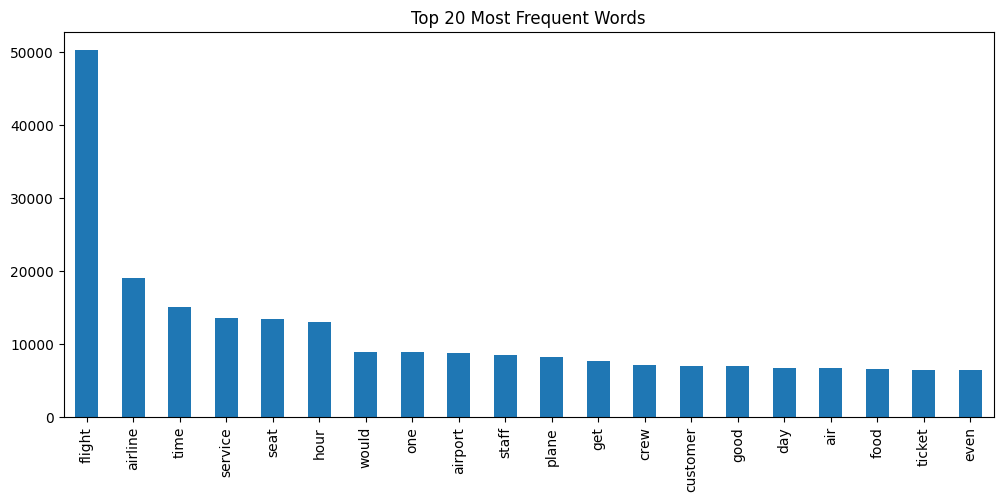

In [ ]:
top_words = bow_df.sum().sort_values(ascending=False).head(20)
top_words.plot(kind='bar', figsize=(12, 5), title='Top 20 Most Frequent Words')

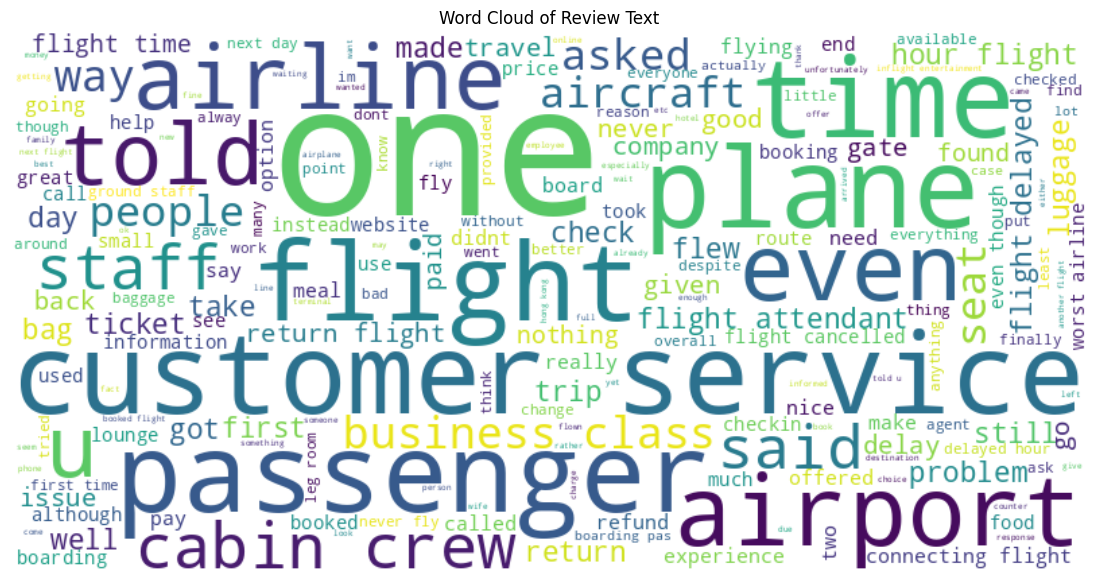

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['Cleaned_Review_Text']))
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Text')
plt.show()

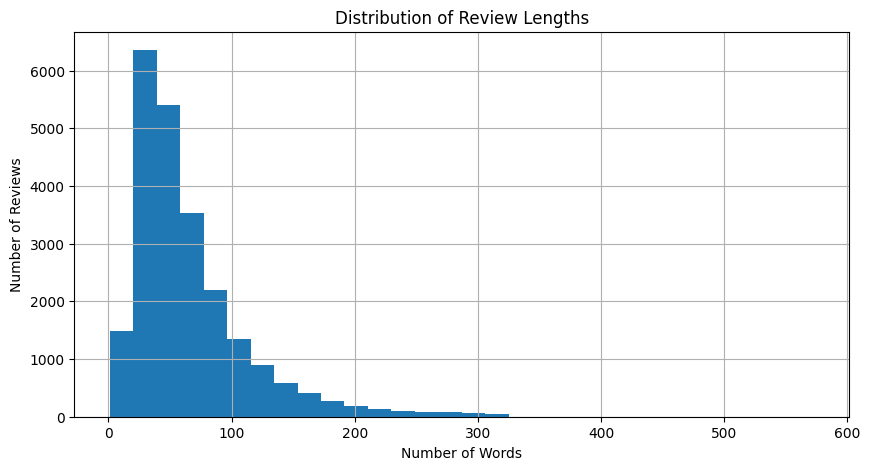

In [ ]:
df['Review_Length'] = df['Cleaned_Review_Text'].apply(lambda x: len(x.split()))
df['Review_Length'].describe()

df['Review_Length'].hist(bins=30, figsize=(10, 5))
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.show()

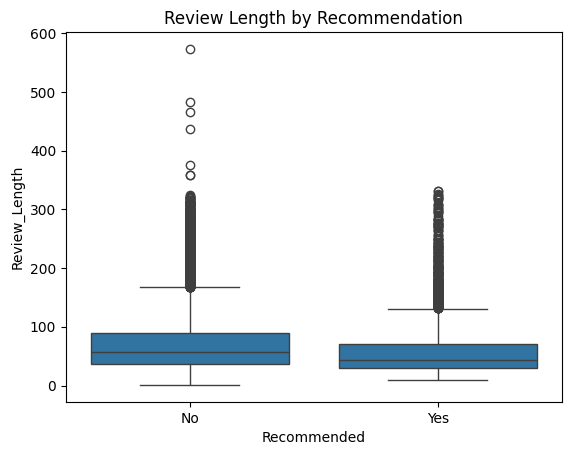

In [ ]:
sns.boxplot(data=df, x='Recommended', y='Review_Length')
plt.title('Review Length by Recommendation')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [ ]:
pip install textblob


In [ ]:
from textblob import TextBlob
import pandas as pd


In [ ]:
def analyze_sentiment(text):
    if pd.isnull(text):
        return "Neutral", 0.0

    blob = TextBlob(text)
    polarity = blob.sentiment.polarity

    if polarity > 0:
        sentiment = "Positive"
    elif polarity < 0:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    return sentiment, polarity


In [ ]:
df[['Sentiment', 'Polarity']] = df['Review'].apply(
    lambda x: pd.Series(analyze_sentiment(x)))


In [ ]:
# Count of each sentiment
print(df['Sentiment'].value_counts())

# Average polarity
print("Average Polarity:", df['Polarity'].mean())


Sentiment
Positive    14377
Negative     8516
Neutral       278
Name: count, dtype: int64
Average Polarity: 0.06757120317799274


<ipython-input-121-c430fe5d6603>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', order=['Positive', 'Neutral', 'Negative'], palette='YlGnBu')


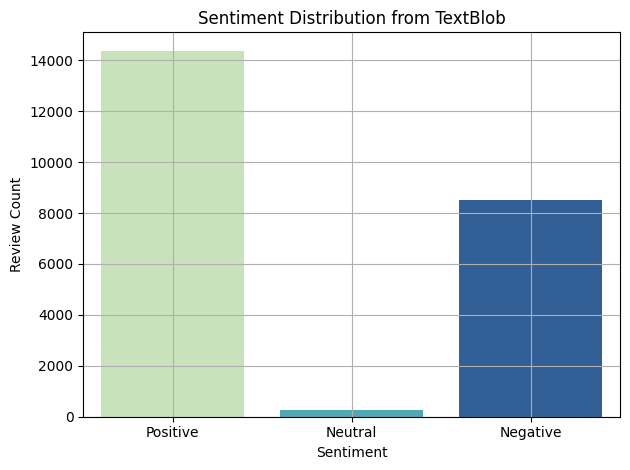

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Sentiment', order=['Positive', 'Neutral', 'Negative'], palette='YlGnBu')
plt.title('Sentiment Distribution from TextBlob')
plt.xlabel('Sentiment')
plt.ylabel('Review Count')
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-122-3f3dde35cb83>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Sentiment', y='Overall_Rating', palette='YlGnBu')


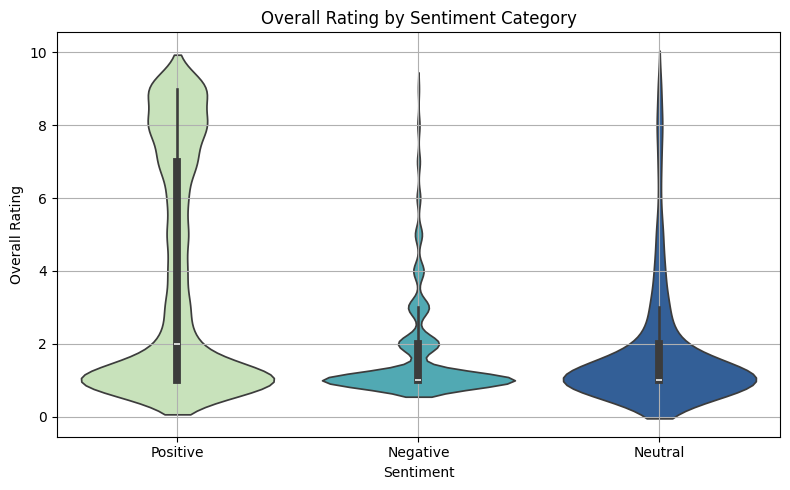

In [ ]:
# Violin plot: Overall Rating vs Sentiment
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Sentiment', y='Overall_Rating', palette='YlGnBu')
plt.title('Overall Rating by Sentiment Category')
plt.xlabel('Sentiment')
plt.ylabel('Overall Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-125-0896f49d58d1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sentiment', y='Seat Comfort', palette='YlGnBu')


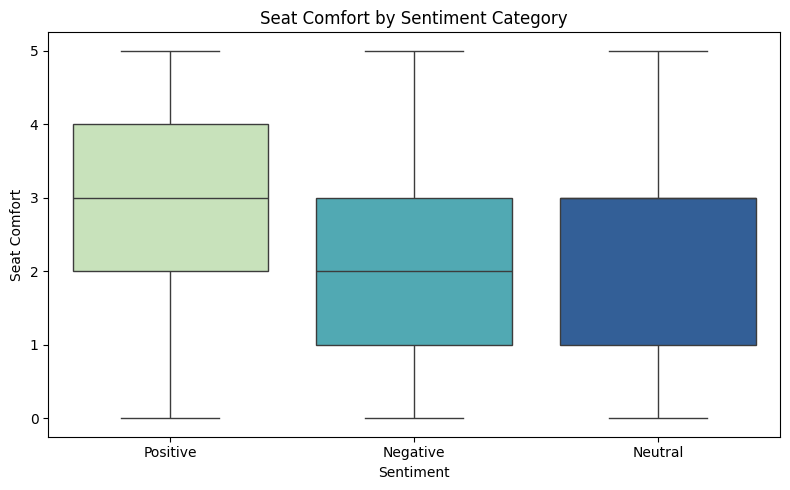

In [ ]:
# Boxplot: Seat Comfort by Sentiment
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Sentiment', y='Seat Comfort', palette='YlGnBu')
plt.title("Seat Comfort by Sentiment Category")
plt.xlabel("Sentiment")
plt.ylabel("Seat Comfort")
plt.tight_layout()
plt.show()

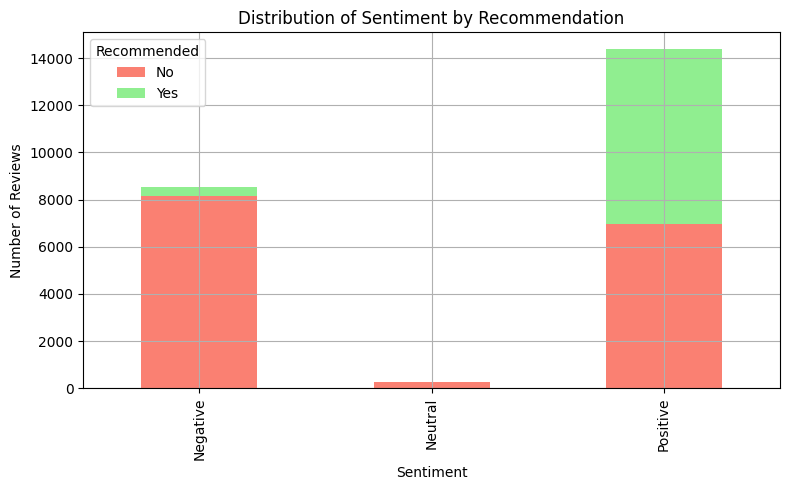

In [ ]:
# Create a crosstab of Sentiment vs Recommended
sentiment_and_recommed = pd.crosstab(df['Sentiment'], df['Recommended'])

# Plot as a stacked bar chart
sentiment_and_recommed.plot(kind='bar', stacked=True, color=['salmon', 'lightgreen'], figsize=(8, 5))
plt.title("Distribution of Sentiment by Recommendation")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.legend(title='Recommended', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

<ipython-input-130-96a30ef5229d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sentiment', y='Review_Length', palette='Set2')


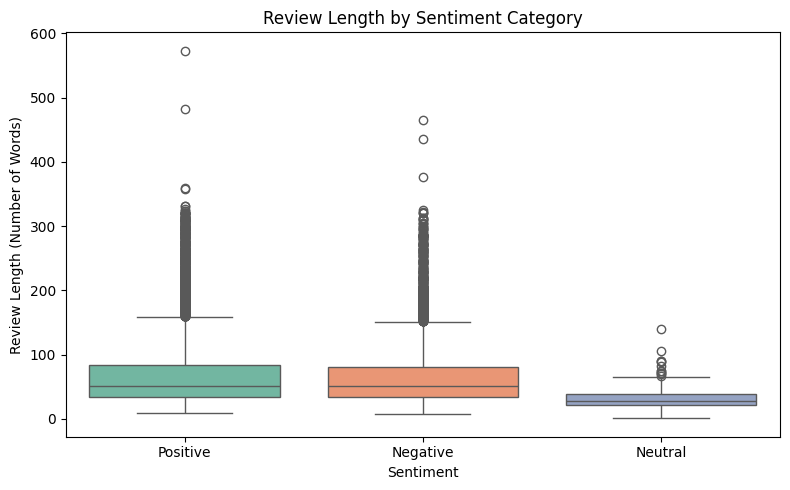

In [ ]:
# Plot review length distribution by sentiment
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Sentiment', y='Review_Length', palette='Set2')
plt.title("Review Length by Sentiment Category")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (Number of Words)")
plt.tight_layout()
plt.show()

<ipython-input-131-ed5fce9e3f1a>:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=melted, x='Service Feature', y='Rating', hue='Sentiment', ci=None)


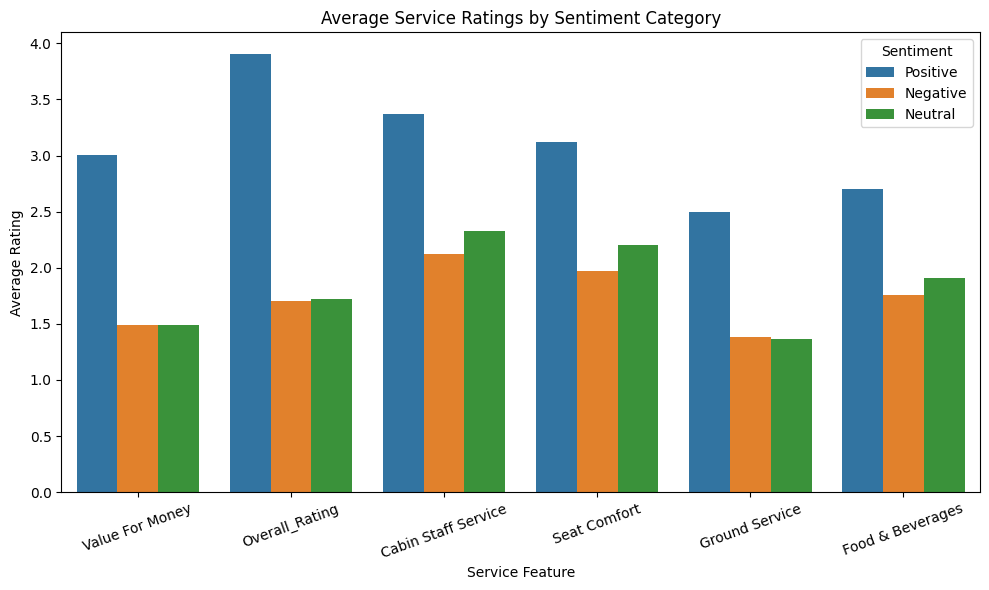

In [ ]:
# Melt the data to long format for seaborn
melted = df.melt(id_vars=['Sentiment'], value_vars=selected_features,
                 var_name='Service Feature', value_name='Rating')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=melted, x='Service Feature', y='Rating', hue='Sentiment', ci=None)
plt.title("Average Service Ratings by Sentiment Category")
plt.ylabel("Average Rating")
plt.xlabel("Service Feature")
plt.legend(title='Sentiment')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Best C: {'C': 0.1}
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      3065
           1       0.87      0.83      0.85      1570

    accuracy                           0.90      4635
   macro avg       0.89      0.88      0.88      4635
weighted avg       0.90      0.90      0.90      4635

AUC Score: 0.9481543209235148


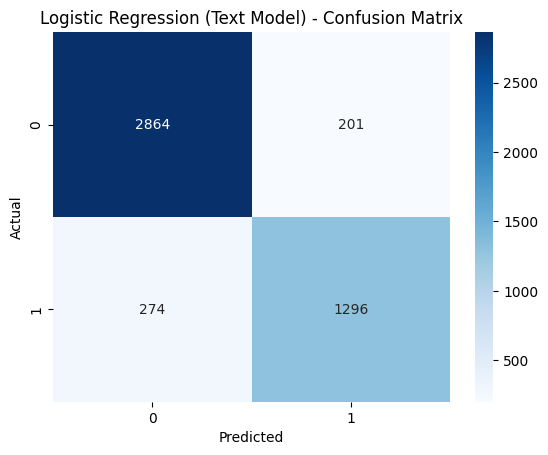

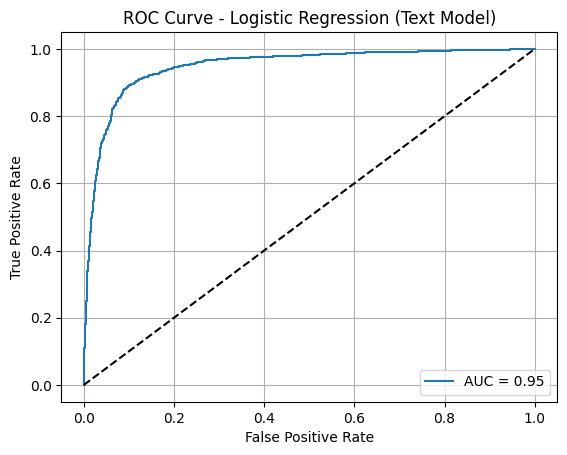

In [ ]:
# Predicting Analyics Text

###################################
# 1. Logistic Regression text
###################################

X = bow_df
y = df['Recommended']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter tuning using GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# Best model
best_text_model = grid.best_estimator_
print("Best C:", grid.best_params_)

# Predict and Evaluate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

y_pred = best_text_model.predict(X_test)
y_probs = best_text_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_probs))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression (Text Model) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_probs):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Logistic Regression (Text Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

<ipython-input-137-fd0debb6aacf>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_combined, x='Coefficient', y='Word', palette='coolwarm')


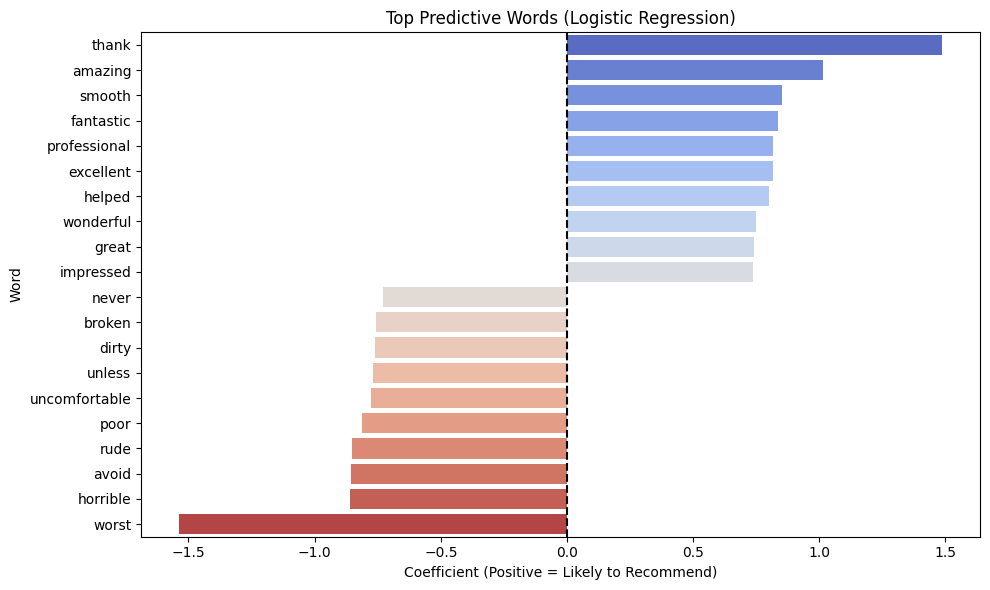

In [ ]:
# Top Predictive Words (Logistic Regression)
# Get coefficients and words
coef = best_text_model.coef_[0]
features = bow_df.columns

# Create DataFrame of features and their coefficients
logreg_importance_df = pd.DataFrame({
    'Word': features,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef)
}).sort_values(by='Abs_Coefficient', ascending=False)

# Top 20 positive and negative predictors
top_pos = logreg_importance_df.sort_values(by='Coefficient', ascending=False).head(10)
top_neg = logreg_importance_df.sort_values(by='Coefficient', ascending=True).head(10)

# Combine for plotting
top_combined = pd.concat([top_pos, top_neg]).sort_values(by='Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_combined, x='Coefficient', y='Word', palette='coolwarm')
plt.axvline(0, color='black', linestyle='--')
plt.title('Top Predictive Words (Logistic Regression)')
plt.xlabel('Coefficient (Positive = Likely to Recommend)')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


In [ ]:
#################
# 2. Random Forest


Best Parameters: {'max_depth': None, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      3065
           1       0.86      0.83      0.84      1570

    accuracy                           0.90      4635
   macro avg       0.89      0.88      0.88      4635
weighted avg       0.90      0.90      0.90      4635

AUC Score: 0.9487561434315938


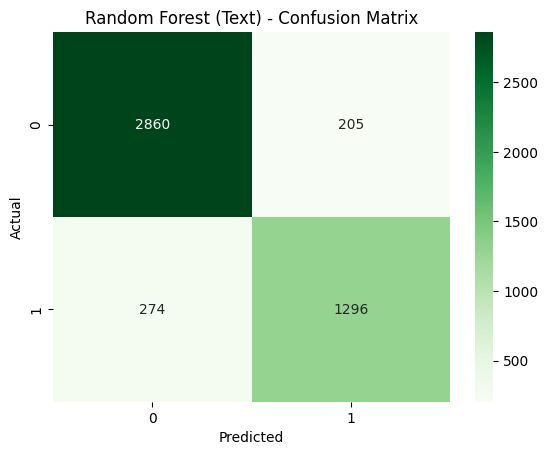

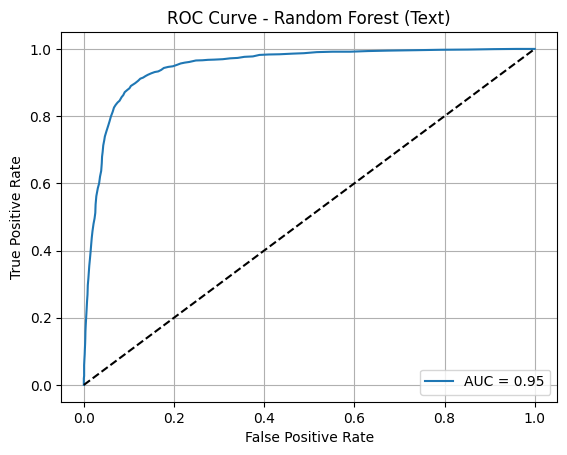

In [ ]:
# Define Features & Target
X = bow_df
y = df['Recommended']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter Tuning
param_grid_rf = {'n_estimators': [100],
                 'max_depth': [10, None]}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

# Best Model & Params
best_rf = grid_rf.best_estimator_
print("Best Parameters:", grid_rf.best_params_)

# Predict
y_pred_rf = best_rf.predict(X_test)
y_probs_rf = best_rf.predict_proba(X_test)[:, 1]


# Evaluation Metrics
print(classification_report(y_test, y_pred_rf))
print("AUC Score:", roc_auc_score(y_test, y_probs_rf))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest (Text) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_score(y_test, y_probs_rf):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Random Forest (Text)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

<ipython-input-139-c1f5ee6eaae6>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='crest')


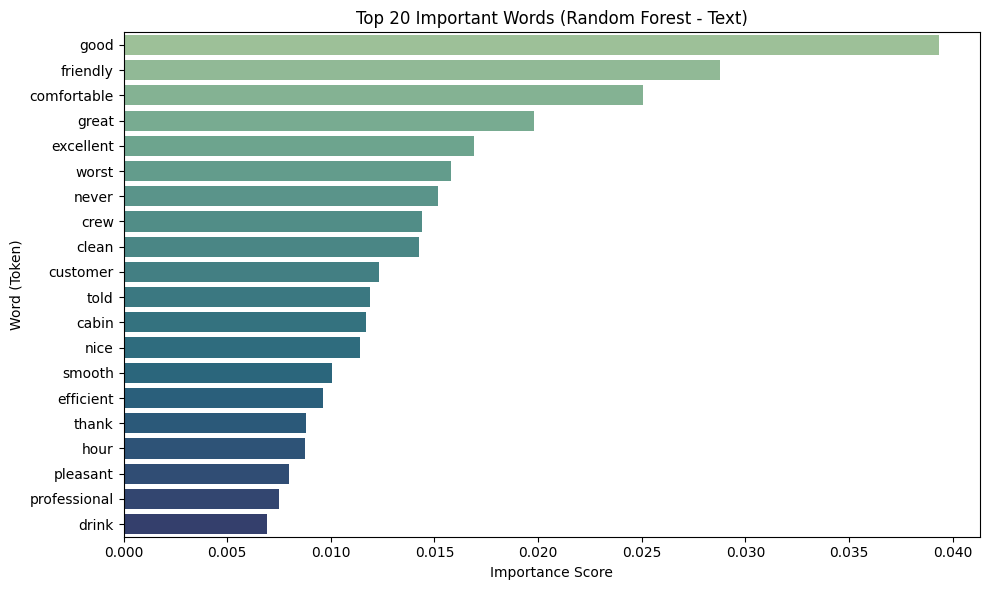

In [ ]:
# Get feature importances from the best Random Forest model
importances = best_rf.feature_importances_
feature_names = bow_df.columns

# Create DataFrame for visualization
import pandas as pd
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)  # Top 20 words

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='crest')
plt.title("Top 20 Important Words (Random Forest - Text)")
plt.xlabel("Importance Score")
plt.ylabel("Word (Token)")
plt.tight_layout()
plt.show()


In [ ]:
################################################################
# Predictive Analytics Combining Numerical and Text Features ###
#################################################################

Best Parameters: LogisticRegression(C=0.01, max_iter=1000)
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      3065
           1       0.94      0.92      0.93      1570

    accuracy                           0.95      4635
   macro avg       0.95      0.95      0.95      4635
weighted avg       0.95      0.95      0.95      4635

AUC Score: 0.9824519695348136


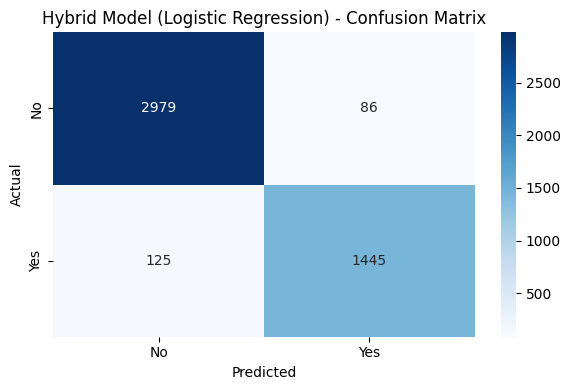

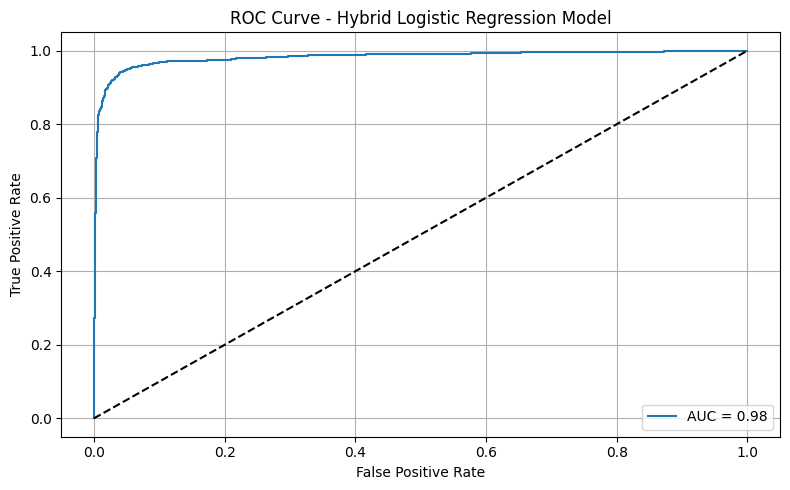

In [ ]:
# 1. Logistic Hybrid

# Scale selected numerical features
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(df[selected_features])
scaled_numerical_df = pd.DataFrame(scaled_numerical, columns=selected_features, index=df.index)

# Combine with text features
X_combined = pd.concat([scaled_numerical_df, bow_df], axis=1)
y_combined = df['Recommended']

# Train-test split
X_train_comb, X_test_comb, y_train_comb, y_test_comb = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42)

# Logistic Regression with Hyperparameter Tuning
param_grid = {'C': [0.01, 0.1, 1, 10]}
grid_comb = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid_comb.fit(X_train_comb, y_train_comb)

best_log_comb = grid_comb.best_estimator_
print("Best Parameters:", best_log_comb)
# Predict and evaluate
y_pred_comb = best_log_comb.predict(X_test_comb)
y_probs_comb = best_log_comb.predict_proba(X_test_comb)[:, 1]

# Evaluation Metrics
print
print(classification_report(y_test_comb, y_pred_comb))
print("AUC Score:", roc_auc_score(y_test_comb, y_probs_comb))

# Confusion Matrix Plot
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_comb, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Hybrid Model (Logistic Regression) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_comb, tpr_comb, _ = roc_curve(y_test_comb, y_probs_comb)
plt.figure(figsize=(8, 5))
plt.plot(fpr_comb, tpr_comb, label=f"AUC = {auc_comb:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Hybrid Logistic Regression Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-146-b68e3927541e>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=logreg_importance_df, x='Coefficient', y='Feature', palette='coolwarm')


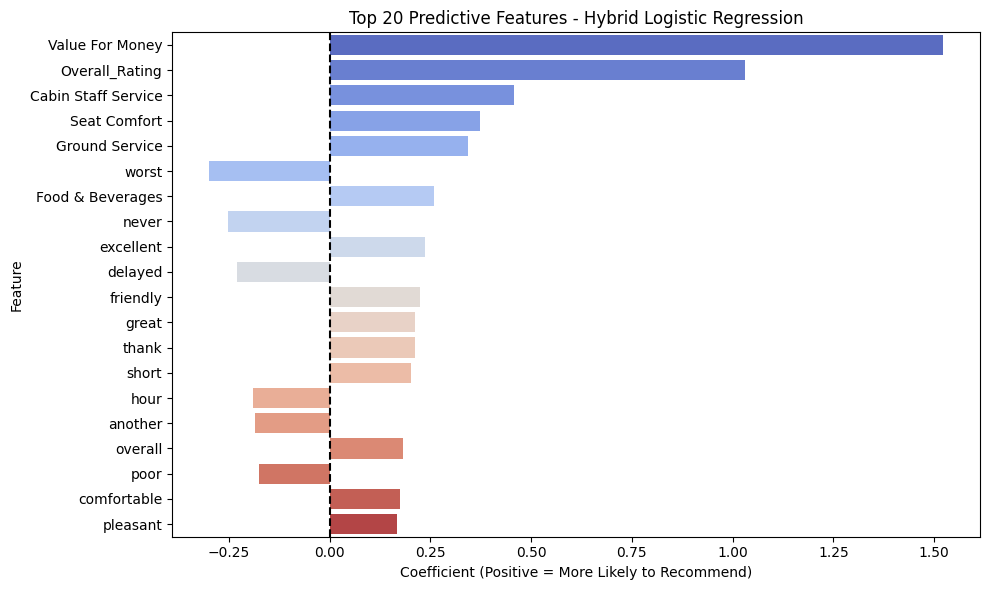

In [ ]:
import numpy as np

# Get coefficients and feature names
coeffs = best_log_comb.coef_[0]
features = X_combined.columns

# Build DataFrame
logreg_importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coeffs,
    'Abs_Coefficient': np.abs(coeffs)
}).sort_values(by='Abs_Coefficient', ascending=False).head(20)  # Top 20

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=logreg_importance_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.axvline(0, color='black', linestyle='--')
plt.title("Top 20 Predictive Features - Hybrid Logistic Regression")
plt.xlabel("Coefficient (Positive = More Likely to Recommend)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
########################
# 2. Random Forest Hybrid
########################


{'n_estimators': [100], 'max_depth': [10, None]}
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3065
           1       0.95      0.94      0.95      1570

    accuracy                           0.96      4635
   macro avg       0.96      0.96      0.96      4635
weighted avg       0.96      0.96      0.96      4635

AUC Score: 0.9890230774825698


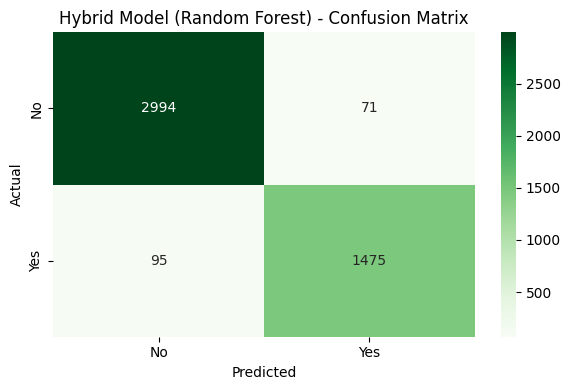

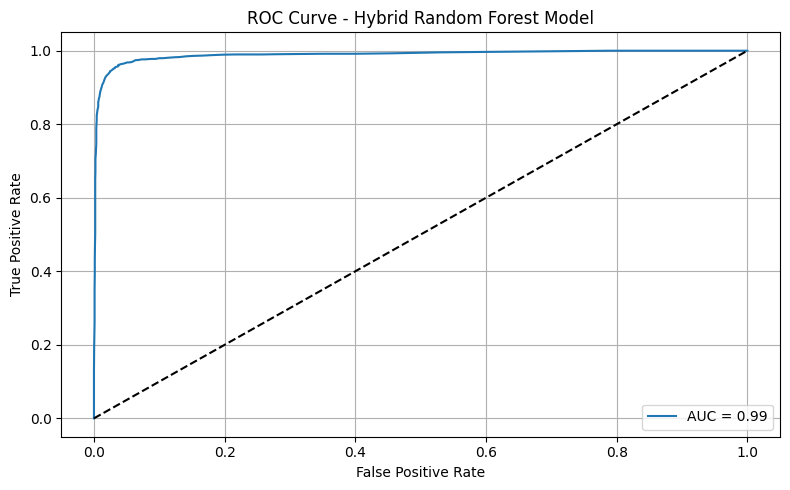

In [ ]:
# Random Forest with Hyperparameter Tuning
param_grid_rf = {'n_estimators': [100],'max_depth': [10, None]}
print(param_grid_rf)
grid_rf_comb = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf_comb.fit(X_train_comb, y_train_comb)

# Best model
best_rf_comb = grid_rf_comb.best_estimator_

# Step 4: Predict and evaluate
y_pred_rf_comb = best_rf_comb.predict(X_test_comb)
y_probs_rf_comb = best_rf_comb.predict_proba(X_test_comb)[:, 1]

print(classification_report(y_test_comb, y_pred_rf_comb))
print("AUC Score:", roc_auc_score(y_test_comb, y_probs_rf_comb))

rf_comb_conf_matrix = confusion_matrix(y_test_comb, y_pred_rf_comb)
rf_comb_class_report = classification_report(y_test_comb, y_pred_rf_comb, output_dict=True)
rf_comb_auc = roc_auc_score(y_test_comb, y_probs_rf_comb)

# Confusion Matrix Plot
plt.figure(figsize=(6, 4))
sns.heatmap(rf_comb_conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Hybrid Model (Random Forest) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_rf_comb, tpr_rf_comb, _ = roc_curve(y_test_comb, y_probs_rf_comb)
plt.figure(figsize=(8, 5))
plt.plot(fpr_rf_comb, tpr_rf_comb, label=f"AUC = {rf_comb_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Hybrid Random Forest Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



<ipython-input-150-07dc8de5a9c4>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


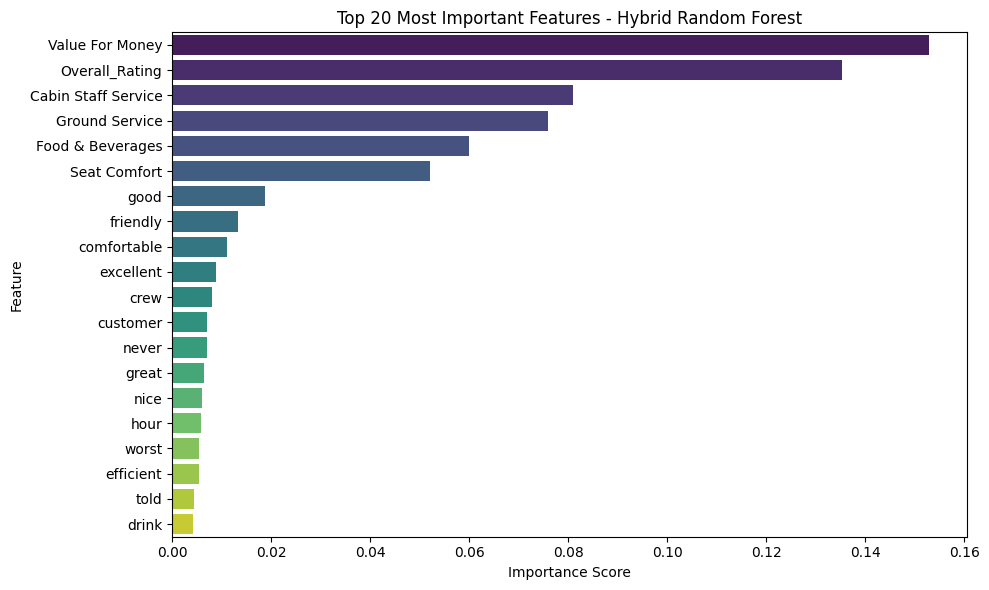

In [ ]:
# Get importances and feature names
importances = best_rf_comb.feature_importances_
feature_names = X_combined.columns

# Create DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)  # Top 20

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Most Important Features - Hybrid Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()